In [11]:
import fipy
print(fipy.__version__)

4.0.3


General Solution:


Eq(p(x), C1*exp(-v*x) + C2)


Derivative:


Eq(dp/dx, -C1*v*exp(-v*x))


Current:


...

0


J(0) =


0


p(1) =


1

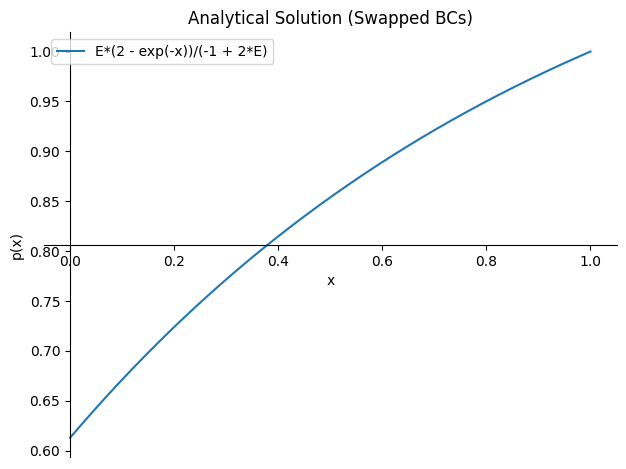

In [12]:
import sympy as sp
from IPython.display import display

# ============================================================
# Symbols
# ============================================================

x = sp.symbols('x', real=True)
v = sp.symbols('v', positive=True)

C1, C2 = sp.symbols('C1 C2')

# ============================================================
# General Solution
# ============================================================

p = C1 * sp.exp(-v*x) + C2

print("General Solution:")
display(sp.Eq(sp.Symbol('p(x)'), p))

# ============================================================
# Derivative
# ============================================================

dpdx = sp.diff(p, x)

print("\nDerivative:")
display(sp.Eq(sp.Symbol('dp/dx'), dpdx))

# ============================================================
# Current
# J = p - (1/v) dp/dx
# ============================================================

J = sp.simplify(p - dpdx/v)

print("\nCurrent:")
display(sp.Eq(sp.Symbol('J(x)'), J))

# ============================================================
# Boundary Conditions
#
# LEFT  : J(0) = 0
# RIGHT : p(1) = 1
# ============================================================

bc1 = sp.Eq(J.subs(x, 0), 0)
bc2 = sp.Eq(p.subs(x, 1), 1)

print("\nBoundary Condition 1:")
display(bc1)

print("\nBoundary Condition 2:")
display(bc2)

# ============================================================
# Solve
# ============================================================

solution = sp.solve((bc1, bc2), (C1, C2), dict=True)

print("\nConstants:")
display(solution)

# ============================================================
# Final Solution
# ============================================================

p_final = sp.simplify(p.subs(solution[0]))

print("\nFinal Analytical Solution:")
display(sp.Eq(sp.Symbol('p(x)'), p_final))

# ============================================================
# Verify PDE
# ============================================================

verification = sp.simplify(
    sp.diff(p_final, x, 2)
    + v * sp.diff(p_final, x)
)

print("\nPDE Verification:")
display(verification)

# ============================================================
# Verify Boundary Conditions
# ============================================================

print("\nJ(0) =")
display(sp.simplify((p_final - sp.diff(p_final, x)/v).subs(x, 0)))

print("\np(1) =")
display(sp.simplify(p_final.subs(x, 1)))

# ============================================================
# Plot (v = 1)
# ============================================================

sp.plot(
    p_final.subs(v, 1),
    (x, 0, 1),
    xlabel="x",
    ylabel="p(x)",
    title="Analytical Solution (Swapped BCs)",
    legend=True
)

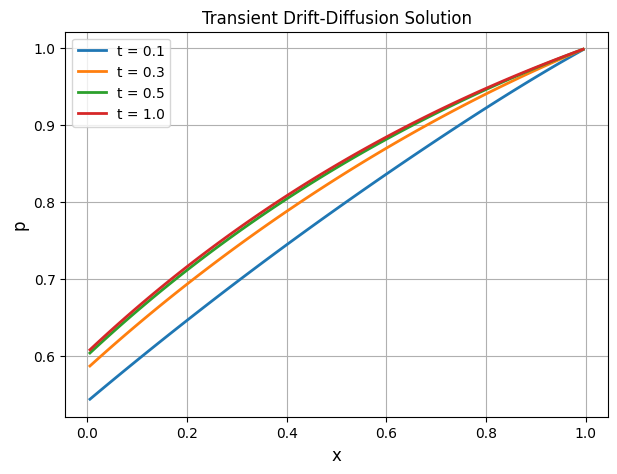

Transient simulation completed.
Final simulation time = 10.0

Boundary Verification
----------------------------------------
Left Robin Boundary
p(left)      = 0.6083282813178391
dp/dx(left)  = 0.6083282813178391
v*p(left)    = 0.6083282813178391

J(left)      = 0.0
----------------------------------------
Right Dirichlet Boundary
p(right)     = 1.0
----------------------------------------


In [13]:
# ============================================================
# PART 2 : TRANSIENT FIPY SOLUTION
# ============================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

L = 1.0
nx = 100
dx = L / nx

v = 1.0

dt = 1e-3
final_time = 10.0
steps = int(final_time / dt)

# ------------------------------------------------------------
# Mesh
# ------------------------------------------------------------

mesh = Grid1D(dx=dx, nx=nx)

x = mesh.cellCenters[0]

# ------------------------------------------------------------
# Initial Condition
# ------------------------------------------------------------

p = CellVariable(
    name='p',
    mesh=mesh,
    value=np.sin(np.pi * x.value)
)

# ------------------------------------------------------------
# RIGHT DIRICHLET BC
#
# p(1)=1
# ------------------------------------------------------------

p.constrain(
    1.0,
    where=mesh.facesRight
)

# ------------------------------------------------------------
# LEFT ROBIN BC
#
# J = p - (1/v) dp/dx = 0
#
# ==> dp/dx = v*p
# ------------------------------------------------------------

p.faceGrad.constrain(
    (((v * p.faceValue,),)),
    where=mesh.facesLeft
)

# ------------------------------------------------------------
# Governing Equation
#
# dp/dt = d²p/dx² + v dp/dx
# ------------------------------------------------------------

eq = (
    TransientTerm()
    ==
    DiffusionTerm(coeff=1)
    +
    ConvectionTerm(coeff=(v,))
)

# ------------------------------------------------------------
# Time Marching
# ------------------------------------------------------------

plot_times = [0.1, 0.3, 0.5, 1.0]

time = 0.0

plt.figure(figsize=(7,5))

for step in range(steps):

    eq.solve(
        var=p,
        dt=dt
    )

    time += dt

    for t in plot_times:

        if abs(time - t) < dt/2:

            plt.plot(
                x.value,
                p.value,
                linewidth=2,
                label=f"t = {time:.1f}"
            )

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.xlabel("x", fontsize=12)
plt.ylabel("p", fontsize=12)

plt.title("Transient Drift-Diffusion Solution")

plt.grid(True)
plt.legend()

plt.show()

# ------------------------------------------------------------
# Save Steady-State Solution
# ------------------------------------------------------------

x_numerical = x.value.copy()
p_numerical = p.value.copy()

print("="*60)
print("Transient simulation completed.")
print("Final simulation time =", final_time)
print("="*60)

# ------------------------------------------------------------
# Verify Boundary Conditions
# ------------------------------------------------------------

print("\nBoundary Verification")
print("-"*40)

print("Left Robin Boundary")
print("p(left)      =", p.faceValue.value[0])
print("dp/dx(left)  =", p.faceGrad[0].value[0])
print("v*p(left)    =", v * p.faceValue.value[0])

print()

J_left = p.faceValue.value[0] - (1/v) * p.faceGrad[0].value[0]

print("J(left)      =", J_left)

print("-"*40)

print("Right Dirichlet Boundary")
print("p(right)     =", p.faceValue.value[-1])

print("-"*40)